In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 


In [2]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
output_paths = list(Path(f"binaural_eval/symmetric_distractor_test/").glob("*/*.pkl"))
stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')

remap_azim = lambda azim: 360 - azim if azim > 90 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'diff'}

for path in output_paths:
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem
    # merge with stim manifest
    df = df.join(stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')  
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    df['snr'] = snr 
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['gender_cond'] = df["gender"].values == df['bg_gender'].values
    df['gender_cond'] =  df['gender_cond'].map(gend_map)
    results_dfs.append(df)
results = pd.concat(results_dfs)

In [3]:
results.head()

,accuracy,confusions,preds,true_word_int,model,word,bg_word,gender,bg_gender,snr,target_azim,target_elev,distractor_azim,distractor_elev,gender_cond
0,0,0,101,135,word_task_half_co_loc_v06,commercial,hours,male,female,-12,0,0,0,0,diff
1,0,0,337,618,word_task_half_co_loc_v06,showed,british,male,female,-12,0,0,0,0,diff
2,0,0,756,693,word_task_half_co_loc_v06,technology,within,female,female,-12,0,0,0,0,same
3,0,1,588,638,word_task_half_co_loc_v06,sound,river,female,female,-12,0,0,0,0,same
4,0,1,420,381,word_task_half_co_loc_v06,lives,minutes,female,female,-12,0,0,0,0,same


In [4]:
grouped_results = results.groupby(['model', 'target_azim', 'distractor_azim', 'gender_cond', 'snr']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
# remove trailing underscore
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]



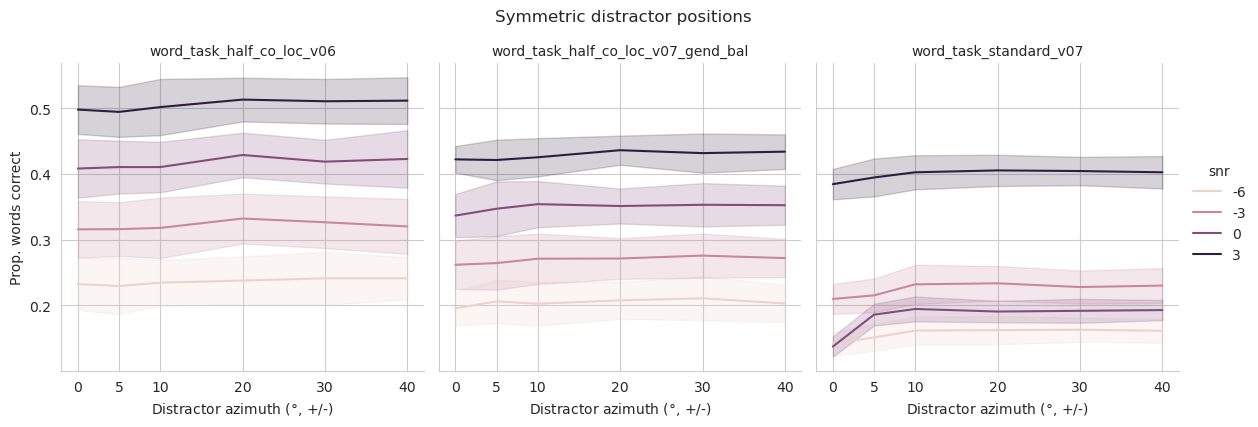

In [10]:
### Plot diotic precedense effect 


# hue_order = ['clean', 'overlap', 'left', 'right', 'center']
# 
# palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

sns.set_style('whitegrid')

to_plot = grouped_results.copy() #& (grouped_results.target_azim == 'center')]
to_plot.loc[to_plot.snr == 'clean', 'snr'] = 6
to_plot = to_plot[to_plot.snr >= -6]
to_plot['distractor_azim'] = to_plot['distractor_azim'].astype(int).abs()
to_plot = to_plot[to_plot.distractor_azim <= 40]


g = sns.relplot(data=to_plot,
                #palette=palette,
                x='distractor_azim', y='accuracy_mean', errorbar=('se', 1), hue="snr",
                kind='line', legend=True,
                col='model',
                # palette=palette, 
                height=4)

# iterate through each facet of the facetgrid
# for azim, ax in g.axes_dict.items():
#     # skip the model facet - we bootstrap above 
#     # select the data for the facet
#     data = to_plot[to_plot['target_azim']==azim]
#     # select the data for each hue group
#     for group, selected in data.groupby('diotic_cond'):
#         if group != 'clean':
#             continue
#         # plot the errorbar with the correct color for each group 
#         print(group)
#         ax.errorbar(data=selected, x="snr", y="accuracy_mean",
#                      yerr="accuracy_sem", capsize=1,ls='none', color=palette[group])

# fix xticks to match azim values
g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Prop. words correct")
g.set_titles("{col_name}")
plt.suptitle("Symmetric distractor positions", y=1.05)
# set xticks of g from -90 to 90 
# g.set(yticks=np.arange(0,  1.1, 0.1))
# g.legend.remove()

x_tick_locs = np.sort(to_plot.distractor_azim.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
# x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
# plt.tight_layout()

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='confusions_mean', hue='gender_cond', kind='line', col='target_azim')

Text(0.5, 1.05, 'Symmetric distractor positions')

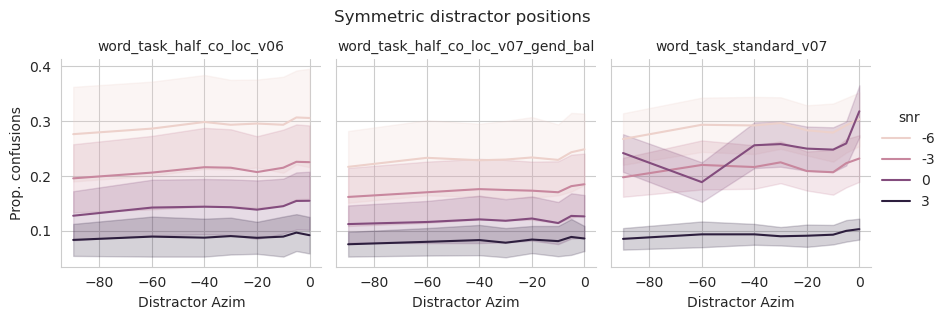

In [6]:
### Plot diotic precedense effect 


# hue_order = ['clean', 'overlap', 'left', 'right', 'center']
# 
# palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

sns.set_style('whitegrid')

to_plot = grouped_results.copy() #& (grouped_results.target_azim == 'center')]
to_plot.loc[to_plot.snr == 'clean', 'snr'] = 6
to_plot = to_plot[to_plot.snr >= -6]

g = sns.relplot(data=to_plot,
                #palette=palette,
                x='distractor_azim', y='confusions_mean', errorbar=('se', 1), hue="snr",
                kind='line', legend=True,
                col='model',
                # palette=palette, 
                height=3)

# iterate through each facet of the facetgrid
# for azim, ax in g.axes_dict.items():
#     # skip the model facet - we bootstrap above 
#     # select the data for the facet
#     data = to_plot[to_plot['target_azim']==azim]
#     # select the data for each hue group
#     for group, selected in data.groupby('diotic_cond'):
#         if group != 'clean':
#             continue
#         # plot the errorbar with the correct color for each group 
#         print(group)
#         ax.errorbar(data=selected, x="snr", y="confusions_mean",
#                      yerr="accuracy_sem", capsize=1,ls='none', color=palette[group])

# fix xticks to match azim values
g.set_axis_labels("Distractor Azim", "Prop. confusions")
g.set_titles("{col_name}")
plt.suptitle("Symmetric distractor positions", y=1.05)
# set xticks of g from -90 to 90 
# g.set(yticks=np.arange(0,  1.1, 0.1))
# g.legend.remove()

# x_tick_locs = np.sort(to_plot.snr.unique())
# x_tick_labels = [str(x) for x in x_tick_locs]
# x_tick_labels[-1] = 'inf'
# for ax in g.axes.flat:
#     labels = ax.get_xticklabels() # get x labels
#     ax.set_xticks(ticks=x_tick_locs) # set new labels
#     ax.set_xticklabels(labels=x_tick_labels)
# plt.tight_layout()

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='confusions_mean', hue='gender_cond', kind='line', col='target_azim')

In [7]:
freyman_grouped_results = results[results.diotic == False].groupby(['model', 'target_azim', 'distractor_azim', 'dist_lead_channel', 'gender_cond',  'snr']).agg({'accuracy':['mean', 'sem'], 'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
freyman_grouped_results.columns = ['_'.join(col).strip() for col in freyman_grouped_results.columns.values]
# remove trailing underscore
freyman_grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in freyman_grouped_results.columns.values]


AttributeError: 'DataFrame' object has no attribute 'diotic'

In [ ]:
10 * 10